# Modelo de Erdös-Rényi

En el modelo de Erdös-Renyi se fijan dos parámetros: 

- $n$: la cantidad de vértices,
- $p$: la probabilidad de que dos vértices distintos de la red están conectados.

Es decir, conectamos dos nodos con una probabilidad independiente $p$. A este modelo se le denota como $G(n,p)$.

## El modelo

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

El siguiente código genera una red aleatoria con $n$ nodos y probabilidad $p$.

In [4]:
def aristas_aleatorias(n, p):
  for i in range(n):
    for j in range(i):
      if np.random.rand() < p:
        yield i,j # yield es como un return pero devuelve un generador, es decir, devuelve un valor cada vez que se le pide, en este caso devuelve una tupla (i,j) cada vez que se cumple la condición de la probabilidad p

def red_aleatoria(n, p):
  G = nx.Graph()
  G.add_nodes_from(range(n)) # agrega todos los nodos

  G.add_edges_from( aristas_aleatorias(n, p) ) # agrega los enlaces obedeciendo la probabilidad p

  return G

Generemos una red aleatoria con 100 nodos y probabilidad 0.5. Puedes cambiar los parámetros para generar otras.

In [5]:
n=101
p=0.5
G = red_aleatoria(n,p)

Podemos tratar de visualizar la red, sin embargo, ya vimos que NetworkX no es para visualización.

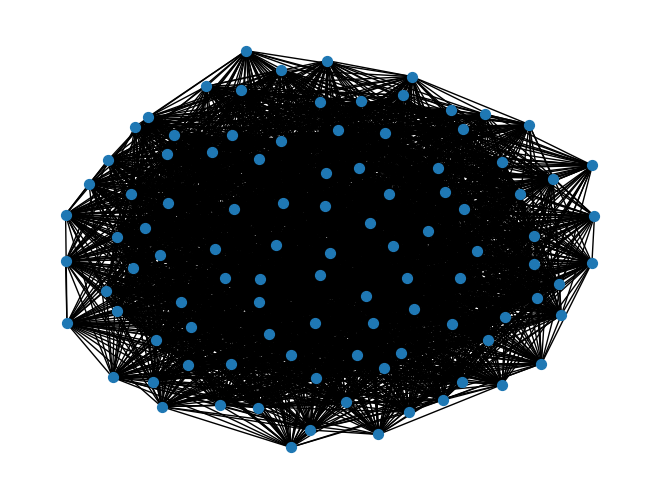

In [6]:
layout=nx.kamada_kawai_layout(G)
nx.draw(G,layout, node_size=50)

Además, estamos interesados en la estructura de las redes de este modelo. Como la distribución de grados.

## Propiedades globales del modelo

Podemos calcular propiedades globales de la red generada, como el número de aristas, el grado promedio y el coeficiente de agrupamiento promedio:

In [7]:
n1 = len(G)
m = len(G.edges)
k = 2*m/n1
C = nx.average_clustering(G)

print('Propiedades generales de la red:')
print('- El número de nodos es:\t', n1)
print('- El número de enlaces es:\t', m)
print('- El grado promedio es:\t\t', k)

print('\n\nEl coeficiente de clustering promedio de la red es:\n', C)

Propiedades generales de la red:
- El número de nodos es:	 101
- El número de enlaces es:	 2542
- El grado promedio es:		 50.336633663366335


El coeficiente de clustering promedio de la red es:
 0.5042318320587863


##### *Recordar que el coeficiente de Clustering indica qué tan frecuente es que dos nodos conectados a un mismo nodo también estén conectados entre sí, formando triángulos. Un valor alto sugiere que la red presenta grupos locales densos o comunidades bien definidas, mientras que un valor bajo indica una estructura más dispersa, donde los vecinos de un nodo rara vez se conectan entre ellos.*

##### *Hace sentido que el grado promedio sea 50 (aprox.) porque es la probabilidad que definimos para conectar nodos. Los enlaces son, igual, $100\times50 / 2$*

In [8]:
print('El número de enlaces es:', 100*50/2) 

El número de enlaces es: 2500.0


Cada red del modelo puede tener propiedades diferentes, para obtener propiedades del modelo, se pueden generar varias redes y obtener el promedio, de cada propiedad, sobre todas las redes.

### Número de aristas esperado

Generemos varias redes para obtener el promedio del número de aristas sobre todas ellas; es decir, el valor esperado del número de aristas.

In [9]:
def erdos_renyi(n, p):
    redes = 100

    # M es la lista en la que se irán guardando los valores de M
    lista_M = []

    for i in range(redes):
        G = red_aleatoria(n,p) # Generamos una red del modelo para cada i
        M = len(G.edges) # Se calcula el número de aristas de la red generada
        lista_M.append(M) # Se agrega el valor a la lista de cantidades de aristas

    print('El valor esperado de m es (Monte Carlo):', np.mean(lista_M))

In [10]:
def formula_erdos_renyi(n, p):
    return print('El valor esperado de m es:', n*(n-1)*p/2)

In [11]:
erdos_renyi(101, 0.5)
formula_erdos_renyi(101, 0.5)

El valor esperado de m es (Monte Carlo): 2525.95
El valor esperado de m es: 2525.0


In [12]:
erdos_renyi(501, 0.1)
formula_erdos_renyi(501, 0.1)

El valor esperado de m es (Monte Carlo): 12510.57
El valor esperado de m es: 12525.0


#  Relacione con $n$ y $p$

Prueba generando más redes. ¿Puedes encontrar una expresión para el valor esperado de $m$ que relacione con $n$ y $p$?

##### *En una red no dirigida simple con $n$ nodos, el número total de aristas posibles es $_n\text{C}_2$. Como en $G(n,p)$ cada arista aparece con probabilidad $p$, multiplicamos.*

$$
\mathbb{E}[m]=p\binom{n}{2}=p\frac{n(n-1)}{2}.
$$

# Grado promedio esperado

Calcula el grado promedio esperado del modelo generando varias redes y obteniendo el promedio de los grados promedios sobre todas las redes generadas. Recuerda que, para cada una de las redes, el grado promedio se puede calcular como $$\langle k\rangle = \frac{2m}{n},$$ en donde $m$ es el número de aristas de la red.

¿Puedes encontrar una expresión para $\langle k\rangle$ que lo relacione con $n$ y $p$?


$$
\mathbb{E}[\langle k\rangle] = \mathbb{E}\left[\frac{2m}{n}\right]  = \frac{2}{n}\mathbb{E}[m]=
\frac{2}{n}\left(p\frac{n(n-1)}{2}\right) = p(n-1)
$$

Entonces: 

$$
\mathbb{E}[\langle k\rangle] = p(n-1).
$$


##### *Esto significa que, en promedio, cada nodo está conectado con una fracción $p$ de los otros $n-1$ nodos posibles.*

# Coeficiente de agrupamiento promedio

Para distintos valores de $n$ y $p$, genera varias redes aleatorias. Para cada modelo calcula su coeficiente de acumulación promedio (varias veces para cada modelo).

¿Se puede encontrar una expresión para el coeficiente de acumulación promedio $C_{WS}$ en términos de $n$ y $p$?

In [13]:
n=101
p=0.5
G = red_aleatoria(n,p)
nx.average_clustering(G)

0.4977396413651604

In [14]:
n=501
p=0.5
G = red_aleatoria(n,p)
nx.average_clustering(G)

0.5002138471132668

In [15]:
n=101
p=0.8
G = red_aleatoria(n,p)
nx.average_clustering(G)

0.7985417692983091

In [16]:
n=101
p=0.1
G = red_aleatoria(n,p)
nx.average_clustering(G)

0.08747424192968747

##### *Si dos nodos son vecinos de un mismo nodo, la probabilidad de que también estén conectados entre sí sigue siendo $p$, ya que las aristas se generan de manera independiente, los triángulos aparecen solo con la frecuencia esperada por azar. Entonces es $C_{WS} = p$*

## Distribución (de probabilidad) de grado

Comencemos haciendo un histograma de grados de la red generada, en la cual recordemos que $n_k$ es la cantidad de nodos con grado $k$.

Text(0.5, 1.0, 'Red aleatoria, n = 100, p = 0.10')

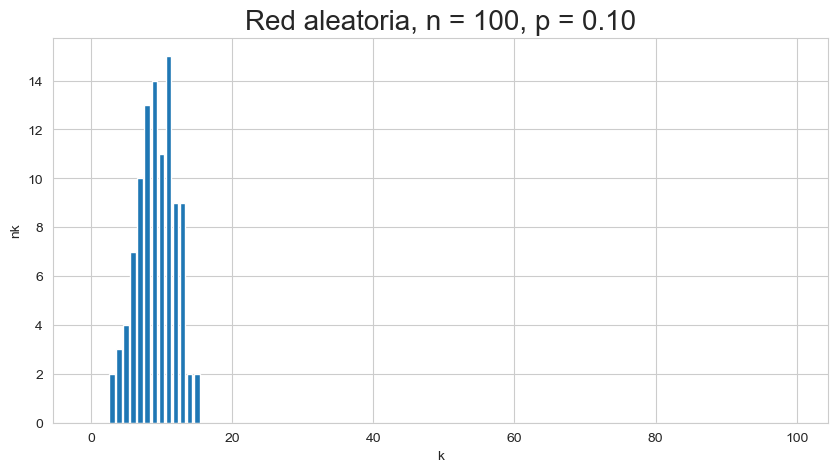

In [17]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n))

plt.figure(figsize = [10,5])
plt.bar(x[:-1],y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title('Red aleatoria, n = %i, p = %1.2f' %(n-1,p), size = 20)

Más aún, nos interesa la gráfica de distribución de grado, es decir, $p_k=\frac{n_k}{n}$.

Text(0.5, 1.0, 'Red aleatoria, n = 100, p = 0.10')

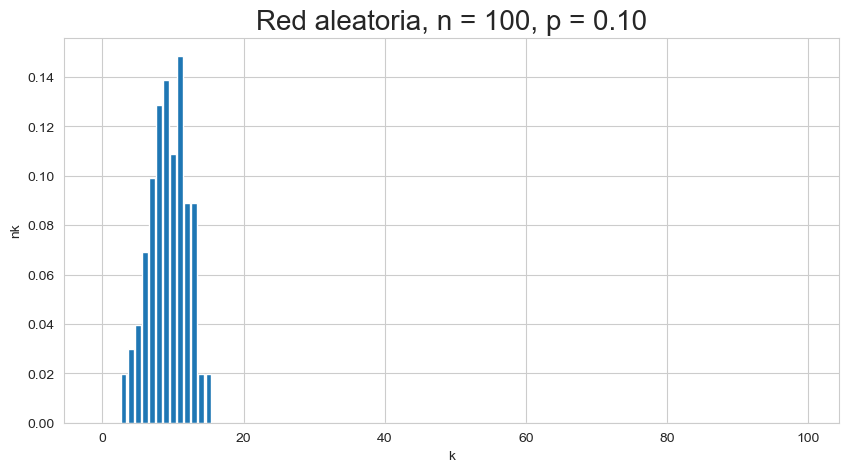

In [18]:
y, x= np.histogram([dict(G.degree)[i] for i in G],bins = range(n), density=True)

plt.figure(figsize = [10,5])
plt.bar(x[:-1],y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title('Red aleatoria, n = %i, p = %1.2f' %(n-1,p), size = 20)

Para analizar las propiedades del modelo, necesitamos generar varias redes muestra y obtener promedios sobre todas ellas. Primero, hagamos un histograma de grados generando 100 redes. Pueden variar los parámetros para ver qué pasa.

Text(0.5, 1.0, 'Red aleatoria, n = 100, p = 0.50')

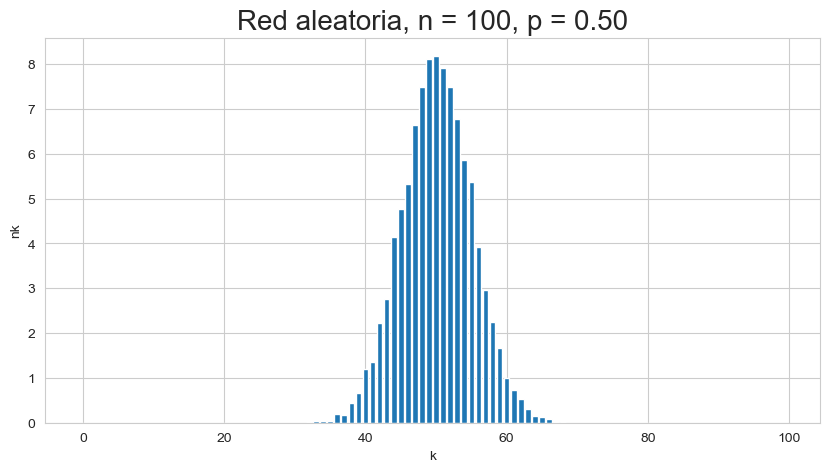

In [19]:
N = 101
p = .5
redes = 100

# Y es el arreglo en el que se acumularán las observaciones para después promediarlas
Y = np.zeros(N-1)

for i in range(redes):
    G = red_aleatoria(n,p)
    y, x = np.histogram([dict(G.degree)[i] for i in G], bins = range(n))
    Y += y

# Se obtiene el promedio sobre todas las redes
Y = Y/redes

# Se grafica
plt.figure(figsize = [10,5])
plt.bar(x[:-1],Y)
plt.xlabel('k', size = 10)
plt.ylabel('nk', size = 10)
plt.title('Red aleatoria, n = %i, p = %1.2f' %(n-1,p), size = 20)

Podemos hacer lo mismo para la distribución de probabilidad de grados y analizar qué distribución es la que aproxima a este modelo. La siguiente línea de código es un spoiler de qué distribución de probabilidad conocida vamos a obtener.

In [20]:
from scipy.stats import binom

Generemos 500 redes del modelo. Pueden cambiar los parámetros.

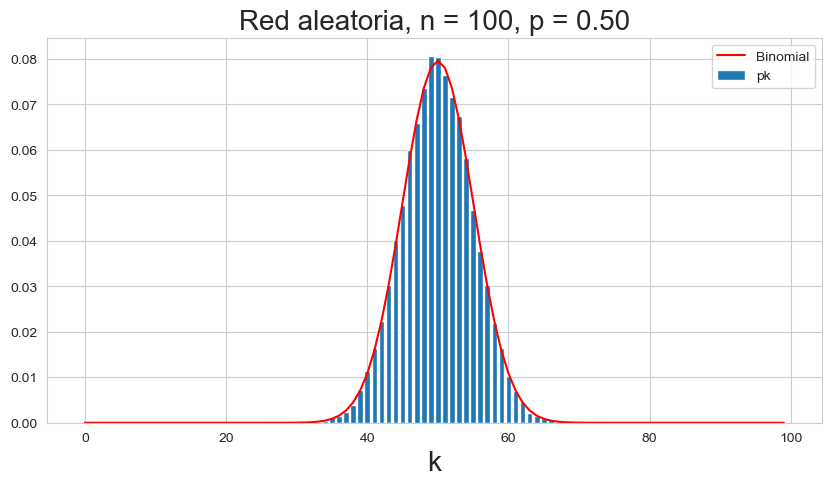

In [21]:
# Se definen los parámetros
n = 101
p = .5
redes = 500

# Y es el arreglo en el que se acumularán las observaciones para luego promediarlas
Y = np.zeros(N-1)

for i in range(redes):
    G = red_aleatoria(n,p)
    y, x = np.histogram([dict(G.degree)[i] for i in G], bins = range(n), density = True)
    Y += y

# Se obtiene el promedio sobre todas las corridas
Y = Y/redes


# Se genera la gráfica
plt.figure(figsize = [10,5])
# La distribución de probabilidad como gráfica de barras
plt.bar(x[:-1],Y, label = 'pk')

# La distribución binomial como una línea roja. Se grafica la función binomial de x, contra x.
plt.plot(x[:-1], binom.pmf(x[:-1],n-1,p), 'r', label = 'Binomial')

# Se ponen los títulos de los ejes y la gráfica
plt.xlabel('k', size = 20)
plt.title('Red aleatoria, n = %i, p = %1.2f' %(n-1,p), size = 20)
plt.legend()

Notemos que se asemeja a una distribución binomial. Veremos en clase por qué.

### Grado promedio

Ahora analicemos el grado promedio del modelo, el cual recordemos que es el promedio (o valor esperado), sobre todas las redes del modelo, del grado promedio: $E[\langle k\rangle]$.

Una forma de hacerlo es comparar las distribuciones de probabilidad de redes distintas, de forma que todas ellas estén centradas en el mismo punto (valor esperado). Puedes variar los parámetros.

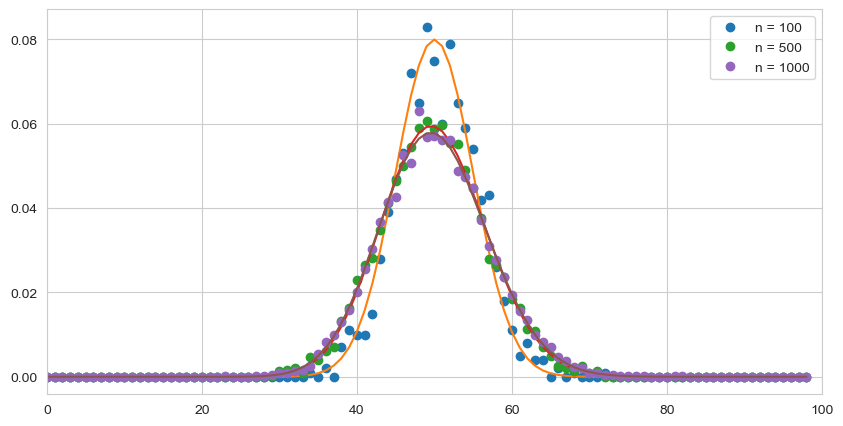

In [22]:
k = 50 # se fija el valor para el grado promedio. La única condición es que debe ser menor que N.


redes = 10 # se puede variar el número de redes. Si es demasiado alto puede tardar mucho para redes grandes


plt.figure(figsize = [10,5])
for n in [100, 500, 1000]: #se tomarán tres redes distintas, para n igual a 100, 500 y 1000. Pueden agregar más grandes pero es posible que tarde mucho
    p = k/(n-1) # SPOILER ALERT del valor esperado del grado promedio

    Y = np.zeros(100-1)

    for i in range(redes):
        G = red_aleatoria(n,p)
        y, x = np.histogram([dict(G.degree)[i] for i in G], bins = range(100), density = True)
        Y += y
    Y = Y/redes

    plt.plot(x[:-1],Y, 'o', label = 'n = '+str(n))
    plt.plot(x[:-1],binom.pmf(x[:-1],n-1,p))

plt.xlim([0,100])
plt.legend()

Ahora veamos qué sucede con redes muy grandes, Generarlas puede tardar mucho tiempo, por lo que analizaremos sus distribuciones, una vez que vimos que siguen una distribución binomial. Fijaremos nuevamente el valor esperado del grado promedio $\langle k \rangle$ y consideraremos las distribuciones para redes de diferentes órdenes de magnitud.

Lo siguiente es un spoiler de la distribución que obtendremos para redes grandes. Todas las distribuciones las compararemos con ella.

In [23]:
from scipy.stats import poisson

Text(0, 0.5, 'pmf(k)')

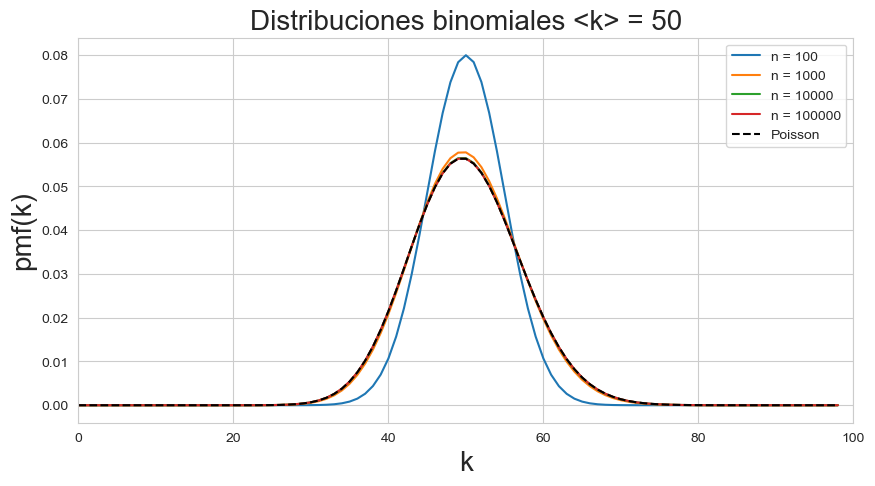

In [24]:
plt.figure(figsize = [10,5])

k = 50
x = np.arange(100)

# Se utilizan cuatro N's en cuatro órdenes:
for n in [10**2, 10**3, 10**4, 10**5]:
    p = k/(n-1)

    plt.plot(x[:-1],binom.pmf(x[:-1], n-1, p), label = 'n = '+str(n))



plt.xlim([0,100])

plt.plot(x[:-1], poisson.pmf(x[:-1], 50), 'k--', label = 'Poisson')

plt.legend()
plt.title('Distribuciones binomiales <k> = 50', size = 20)
plt.xlabel('k', size = 20)
plt.ylabel('pmf(k)', size = 20)

Notemos que para $n$ suficientemente grade, las redes siguen una distribución de Poisson. En clase veremos por qué.

## Coeficiente de agrupamiento

Vamos a comparar el coeficiente de acumulación promedio con la probabilidad $p$. Más aún, vamos a comparar el coeficiente de agrupamiento de cada nodo con $p$. Para ello vamos a graficar. Pueden variar los parámetros para responder ¿cuál es la relación entre estos valores?

El coeficiente de acumulación promedio es:
 0.6890532416278018
La probabilidad de enlace p es:
 0.7


<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

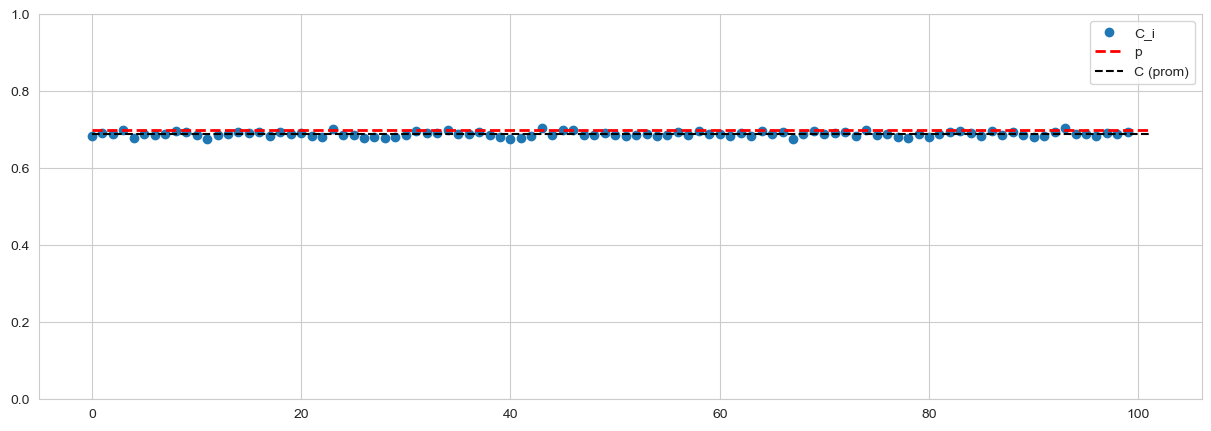

In [25]:
n = 100
p = .7



G = red_aleatoria(n,p)
C = nx.average_clustering(G)
print('El coeficiente de acumulación promedio es:\n', C)
print('La probabilidad de enlace p es:\n', p)

diccionario = nx.clustering(G)
Y = [diccionario[i] for i in G]

plt.figure(figsize = [15,5])
plt.plot(Y, 'o', label = 'C_i')
plt.plot([0,N], [p,p], 'r--', linewidth = 2, label = 'p')
plt.plot([0,N], [C,C], 'k--', label = 'C (prom)')
plt.ylim([0,1])

plt.legend()
plt.xlabel

Veremos en clase por qué se tiene esta relación.

No voy a estar en esa clase por la EPE26 :(